<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Modulo2/Semana3/Semana3_Introdu%C3%A7%C3%A3o_a_imagens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform, color, filters # Novas importações para manipulação

print("="*60)
print("AULA 3: QUEBRA DE PARADIGMA - IMAGENS COMO DADOS")
print("="*60)

print("\n-> O Keras não 'vê' fotos. Ele calcula tensores numéricos.")
print("Vamos provar isso dissecando imagens reais da biblioteca skimage.\n")

img_cinza = data.camera() # Imagem em Escala de Cinza (512x512)
img_cor = data.astronaut() # Imagem Colorida RGB (512x512x3)

AULA 3: QUEBRA DE PARADIGMA - IMAGENS COMO DADOS

-> O Keras não 'vê' fotos. Ele calcula tensores numéricos.
Vamos provar isso dissecando imagens reais da biblioteca skimage.



In [6]:
# ==============================================================================
# TÓPICO 1: REPRESENTAÇÃO, PIXELS E RESOLUÇÕES
# ==============================================================================
print("[TÓPICO 1] ANATOMIA DO TENSOR VISUAL")
print(f"1. Escala de Cinza: {img_cinza.shape} -> (512 Linhas x 512 Colunas)")
print(f"2. Colorida (RGB): {img_cor.shape} -> (512 Linhas x 512 Colunas x 3 Canais)")

[TÓPICO 1] ANATOMIA DO TENSOR VISUAL
1. Escala de Cinza: (512, 512) -> (512 Linhas x 512 Colunas)
2. Colorida (RGB): (512, 512, 3) -> (512 Linhas x 512 Colunas x 3 Canais)


In [7]:
print(img_cinza)

[[200 200 200 ... 189 190 190]
 [200 199 199 ... 190 190 190]
 [199 199 199 ... 190 190 190]
 ...
 [ 25  25  27 ... 139 122 147]
 [ 25  25  26 ... 158 141 168]
 [ 25  25  27 ... 151 152 149]]


In [8]:
# ==============================================================================
# TÓPICO 2: CANAIS (RGB SÃO 3 MATRIZES EMPILHADAS)
# ==============================================================================
print("\n[TÓPICO 2] SEPARANDO OS CANAIS DE COR")
# Fatiando a matriz 3D para isolar as cores (Red, Green, Blue)
canal_r = img_cor[:, :, 0] # Pega todas linhas, todas colunas, apenas o canal 0
canal_g = img_cor[:, :, 1]
canal_b = img_cor[:, :, 2]
print("-> Canais RGB separados! Cada cor agora é uma matriz 2D isolada.")


[TÓPICO 2] SEPARANDO OS CANAIS DE COR
-> Canais RGB separados! Cada cor agora é uma matriz 2D isolada.


In [12]:
# ==============================================================================
# TÓPICO 3: MANIPULAÇÃO E PRÉ-PROCESSAMENTO INDUSTRIAL
# ==============================================================================
print("\n[TÓPICO 3] MANIPULAÇÃO MATEMÁTICA DE IMAGENS")

# A. SLICING (Recorte): Focando em uma região de interesse (ROI - Region of Interest)
rosto = img_cinza[70:160, 160:260]
print(f"A. Recorte do Rosto (ROI): Nova resolução é {rosto.shape}")

# B. ZERANDO PIXELS: Simulando um defeito na lente da câmera (Tarja Preta = 0)
img_com_defeito = img_cinza.copy()
img_com_defeito[300:400, 300:400] = 0

# C. REDUÇÃO DE RESOLUÇÃO (RESIZING): Crucial para Redes Neurais
# Reduzir de 512x512 para 64x64 alivia absurdamente a memória RAM do computador.
img_reduzida = transform.resize(img_cor, (64, 64))
print(f"C. Resizing (Compressão): A imagem de {img_cor.shape} virou {img_reduzida.shape}")

# D. DETECÇÃO DE BORDAS (Filtro Sobel)
# Este é o princípio matemático do que as CNNs (Módulo 2 - Sem 4) farão sozinhas!
img_bordas = filters.sobel(img_cinza)
print("D. Filtro Sobel aplicado: A matemática destacou apenas os contornos da imagem.")


[TÓPICO 3] MANIPULAÇÃO MATEMÁTICA DE IMAGENS
A. Recorte do Rosto (ROI): Nova resolução é (90, 100)
C. Resizing (Compressão): A imagem de (512, 512, 3) virou (64, 64, 3)
D. Filtro Sobel aplicado: A matemática destacou apenas os contornos da imagem.


In [13]:
# ==============================================================================
# O GARGALO DOS MODELOS CLÁSSICOS (FLATTEN)
# ==============================================================================
print("\n[O GARGALO] POR QUE NÃO USAMOS REDES DENSAS AQUI?")
# Redes Densas (como a do Sonar) exigem que os dados sejam uma linha reta (Vetor 1D).
# Se achatarmos a foto original (512x512x3)...
vetor_1d = img_cor.flatten()
print(f"Ao achatar a foto original, geramos um vetor com {len(vetor_1d)} colunas numéricas!")
print("Nenhum modelo clássico lida bem com quase 1 milhão de colunas de entrada.")
print("A Solução: CNNs (Redes Neurais Convolucionais) na próxima semana!\n")


[O GARGALO] POR QUE NÃO USAMOS REDES DENSAS AQUI?
Ao achatar a foto original, geramos um vetor com 786432 colunas numéricas!
Nenhum modelo clássico lida bem com quase 1 milhão de colunas de entrada.
A Solução: CNNs (Redes Neurais Convolucionais) na próxima semana!



-> Abrindo Painel 1: Anatomia e Canais...


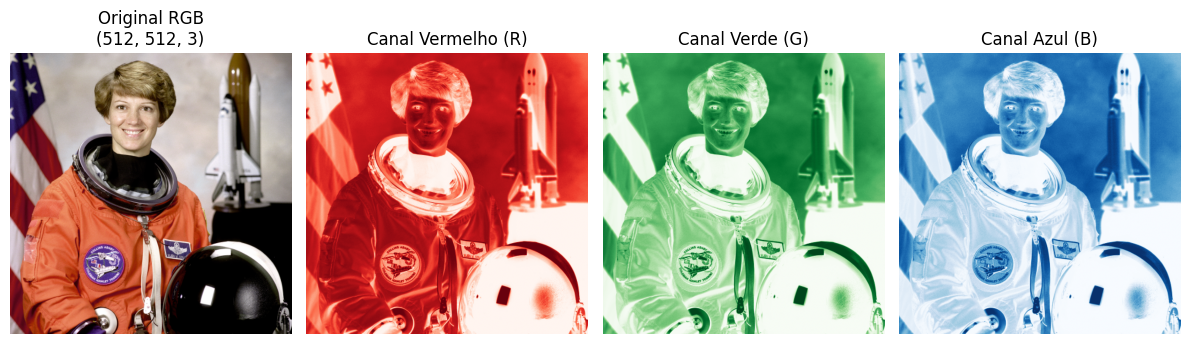

-> Abrindo Painel 2: Manipulação e Filtros...


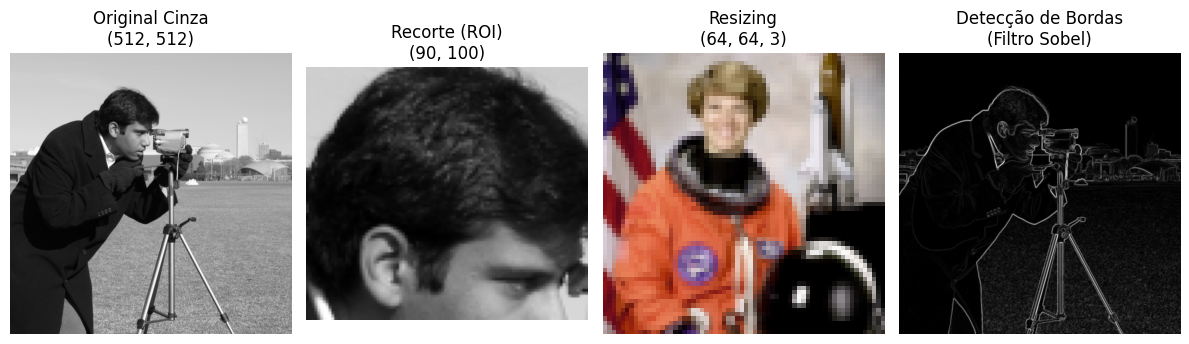

MISSÃO CUMPRIDA! FIM DA SEMANA 3.


In [14]:
# ==============================================================================
# RENDERIZANDO OS RESULTADOS (MATPLOTLIB)
# ==============================================================================
print("-> Abrindo Painel 1: Anatomia e Canais...")
fig1 = plt.figure(figsize=(12, 6))

fig1.add_subplot(1, 4, 1).imshow(img_cor)
plt.title(f"Original RGB\n{img_cor.shape}")
plt.axis('off')

fig1.add_subplot(1, 4, 2).imshow(canal_r, cmap='Reds')
plt.title("Canal Vermelho (R)")
plt.axis('off')

fig1.add_subplot(1, 4, 3).imshow(canal_g, cmap='Greens')
plt.title("Canal Verde (G)")
plt.axis('off')

fig1.add_subplot(1, 4, 4).imshow(canal_b, cmap='Blues')
plt.title("Canal Azul (B)")
plt.axis('off')

plt.tight_layout()
plt.show()

print("-> Abrindo Painel 2: Manipulação e Filtros...")
fig2 = plt.figure(figsize=(12, 6))

fig2.add_subplot(1, 4, 1).imshow(img_cinza, cmap='gray')
plt.title(f"Original Cinza\n{img_cinza.shape}")
plt.axis('off')

fig2.add_subplot(1, 4, 2).imshow(rosto, cmap='gray')
plt.title(f"Recorte (ROI)\n{rosto.shape}")
plt.axis('off')

fig2.add_subplot(1, 4, 3).imshow(img_reduzida)
plt.title(f"Resizing\n{img_reduzida.shape}")
plt.axis('off')

fig2.add_subplot(1, 4, 4).imshow(img_bordas, cmap='gray')
plt.title("Detecção de Bordas\n(Filtro Sobel)")
plt.axis('off')

plt.tight_layout()
plt.show()

print("="*60)
print("MISSÃO CUMPRIDA! FIM DA SEMANA 3.")
print("="*60)